# ***DATA VISUALISATIONS***

This notebook to explore visualisations on our cleaned dataset to understand different trends and patterns that will help us understand how this data works

### **Importing Libraries**

First we will import libraries for visualisations

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Importing dataset**

Now we will import our cleaned dataset we had saved

In [3]:
df = pd.read_csv("cleaned_sales_data.csv")

In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,DiscountedPrice,SellThroughRate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


### **Visualisations**

Now that we have imported the required libraries and the dataset, let us proceed to making visualisations

##### **Demand Distribution**

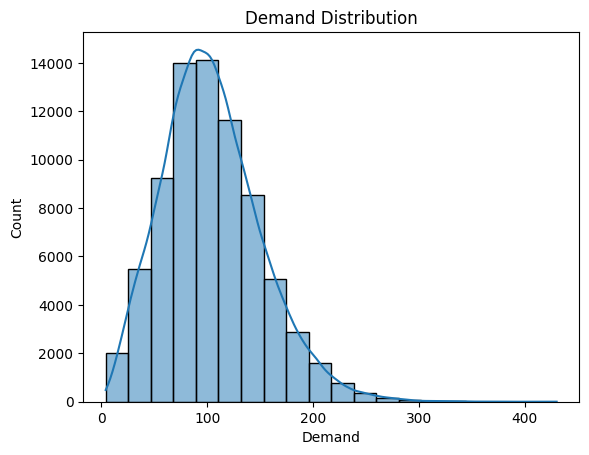

In [5]:
sns.histplot(df["Demand"], bins = 20, kde = True)
plt.title("Demand Distribution")
plt.show()

##### **Inventory vs. Units Sold**

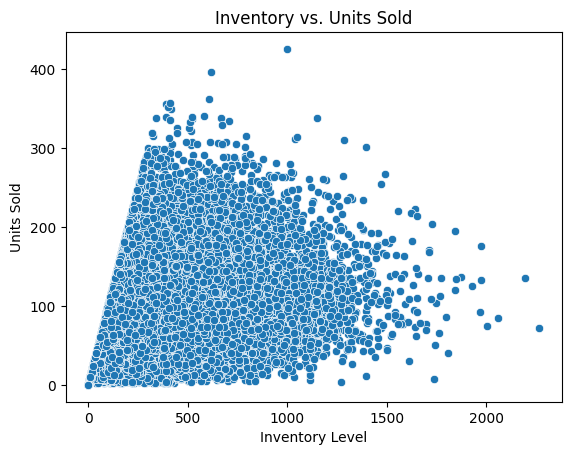

In [6]:
sns.scatterplot(data = df, x = "Inventory Level", y = "Units Sold")
plt.title("Inventory vs. Units Sold")
plt.show()

##### **Demand vs. Category**

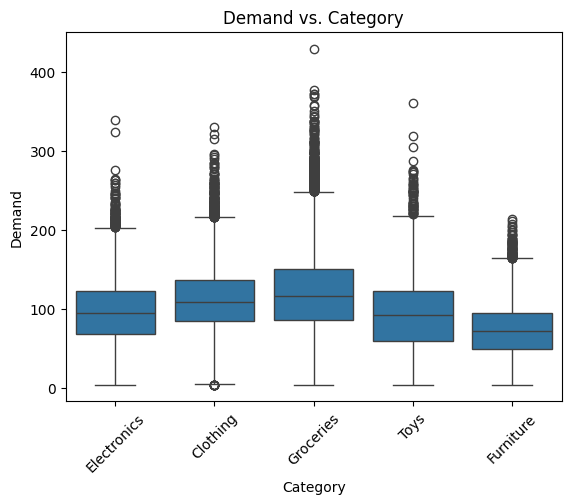

In [8]:
sns.boxplot(data = df, x = "Category", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand vs. Category")
plt.show()

##### **Demand vs. Weather**

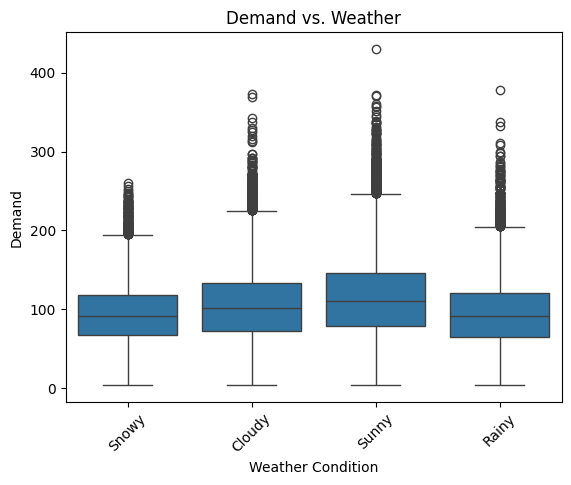

In [9]:
sns.boxplot(data = df, x = "Weather Condition", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand vs. Weather")
plt.show()

Logically, more people opt for shopping during sunny and cloudy days more than rainy or snowy days which also reflects in the box plot here 

Now we will perform time-series analysis which means data that involves time related entries we have including year, month, etc. for which also we will create visualisations as well

First we can start by creating `monthly_demand` we will work with 

In [10]:
monthly_demand = df.groupby("Month")["Demand"].mean()

In [11]:
monthly_demand

Month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

##### **Average demand by Month**

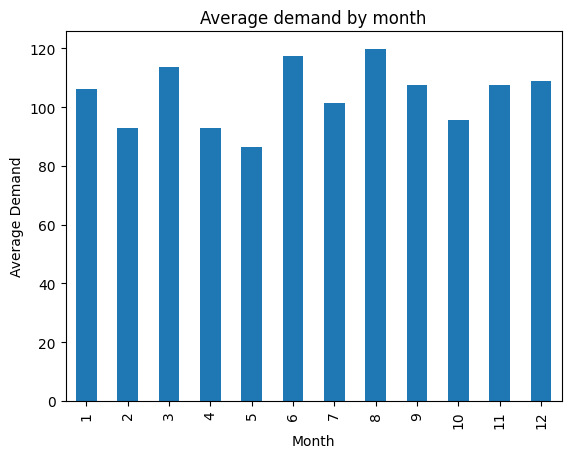

In [12]:
monthly_demand.plot(kind = "bar")
plt.title("Average demand by month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.show()

Now lets create `daily_demand` similarly

In [24]:
daily_demand = df.groupby("Day")["Demand"].mean()

In [25]:
daily_demand

Day
1     102.026400
2     107.125200
3     105.120000
4     105.227600
5     106.291200
6     105.468800
7     102.620800
8     104.821600
9     105.244400
10    103.926000
11    105.776800
12    104.250400
13    104.889600
14    103.350400
15    107.053200
16    104.385200
17    106.167600
18    104.734800
19    104.551200
20    104.268400
21    103.536800
22    104.808400
23    103.572400
24    102.459200
25    105.084800
26    110.078400
27    107.659600
28    106.464400
29     96.614783
30     94.186957
31     97.750714
Name: Demand, dtype: float64

##### **Average demand by Day**

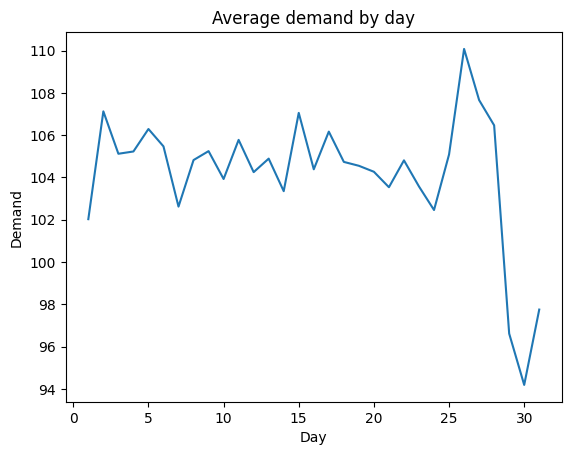

In [28]:
daily_demand.plot()
plt.title("Average demand by day")
plt.xlabel("Day")
plt.ylabel("Demand")
plt.show()


Through this graph we can clearly see that the average demand drop after 26-27th day of the month

##### **Discounted Price vs. Demand**

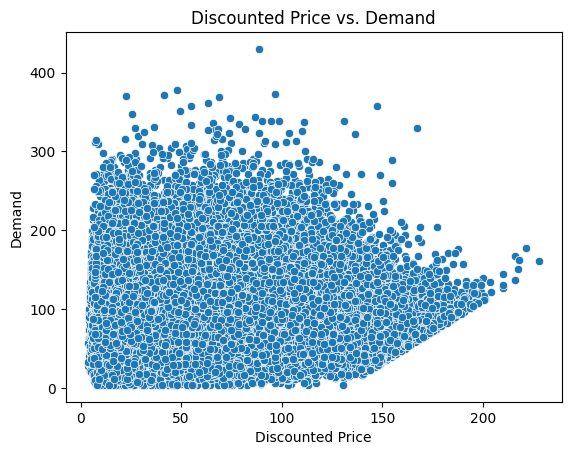

In [32]:
sns.scatterplot(data = df, x = "DiscountedPrice", y = "Demand")
plt.title("Discounted Price vs. Demand")
plt.xlabel("Discounted Price")
plt.show()

##### **Average demand by Season**

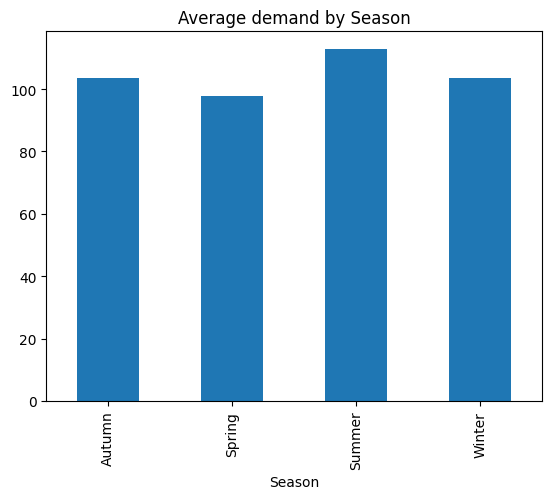

In [34]:
df.groupby("Seasonality")["Demand"].mean().plot(kind = "bar")
plt.title("Average demand by Season")
plt.xlabel("Season")
plt.show()

There is not much difference in the demands based on season but Summer has slight more average demand which is `~110` as compared to Spring which has `~95`

##### **Affect of an epidemic on demand**

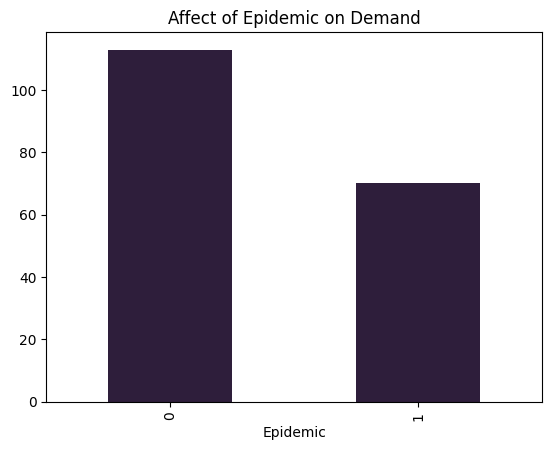

In [47]:
df.groupby("Epidemic")["Demand"].mean().plot(kind = "bar")
plt.title("Affect of Epidemic on Demand")
plt.show()

Again this is logical and true as well that an Epidemic leads to a quite low average demand as compared to normal scenario

From here most of the visualisations that help us to understand the dataset are done and we can start building the ML Model